# 스케줄링 GA 실행 결과

## 환경 설정

In [58]:
BASE_DATA_PATH = 'data/small_data'

## 모듈 import

In [59]:
import time
import random
import simpy
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Scheduler
from algorithms.genetic.encoder import encode
from algorithms.genetic.decoder import decode
from algorithms.genetic.ga import GA

## 데이터 로드

In [60]:
data = DataLoader(BASE_DATA_PATH).load_all_data()

print('데이터 개요')
print(f'Jobs:        {len(data["jobs"])}개')
print(f'Operations:  {len(data["operations"])}개')
print(f'Machines:    {len(data["machines"])}개')

데이터 개요
Jobs:        10개
Operations:  35개
Machines:    8개


## 인코딩

In [61]:
encoded = encode(data)

print(f'job_index_table 길이:       {len(encoded.job_index_table)}')
print(f'machine_index_table 길이:   {len(encoded.machine_index_table)}')
print(f'operation_index_table 길이: {len(encoded.operation_index_table)}')
print(f'pm_levels:                  {encoded.pm_levels}')

job_index_table 길이:       10
machine_index_table 길이:   8
operation_index_table 길이: 35
pm_levels:                  [0.05, 0.1, 0.2, 0.5, 1.0]


## GA 실행

In [62]:
ga = GA(
    encoded=encoded,
    data=data,
    pop_size=100,
    n_generations=60,
    crossover_rate=0.8,
    mutation_rate=0.1,
    tournament_k=3,
    n_elites=2,
    alpha=1.0,
    seed=500,
    verbose=True,         #출력여부
    verbose_interval=1,   #출력세대단위
)

t0 = time.time()
best, history = ga.run()
elapsed = time.time() - t0

print(f'\nGA 실행 시간: {elapsed:.2f}초 ({elapsed/60:.2f}분)')

[Gen   0] best_fitness=188.98  makespan=185.00  qtime=3.98  avg=381.62
[Gen   1] best_fitness=188.98  makespan=185.00  qtime=3.98  avg=334.78
[Gen   2] best_fitness=188.98  makespan=185.00  qtime=3.98  avg=331.50
[Gen   3] best_fitness=188.98  makespan=185.00  qtime=3.98  avg=333.01
[Gen   4] best_fitness=186.91  makespan=178.54  qtime=8.37  avg=331.70
[Gen   5] best_fitness=181.00  makespan=168.00  qtime=13.00  avg=315.75
[Gen   6] best_fitness=181.00  makespan=168.00  qtime=13.00  avg=295.36
[Gen   7] best_fitness=181.00  makespan=168.00  qtime=13.00  avg=296.73
[Gen   8] best_fitness=161.00  makespan=160.00  qtime=1.00  avg=291.38
[Gen   9] best_fitness=161.00  makespan=160.00  qtime=1.00  avg=279.60
[Gen  10] best_fitness=161.00  makespan=160.00  qtime=1.00  avg=270.89
[Gen  11] best_fitness=161.00  makespan=160.00  qtime=1.00  avg=272.42
[Gen  12] best_fitness=161.00  makespan=160.00  qtime=1.00  avg=268.78
[Gen  13] best_fitness=161.00  makespan=160.00  qtime=1.00  avg=264.09
[Ge

## 수렴 곡선

세대별 best/avg fitness 추이 + best의 두 지표(makespan, qtime) 변화.

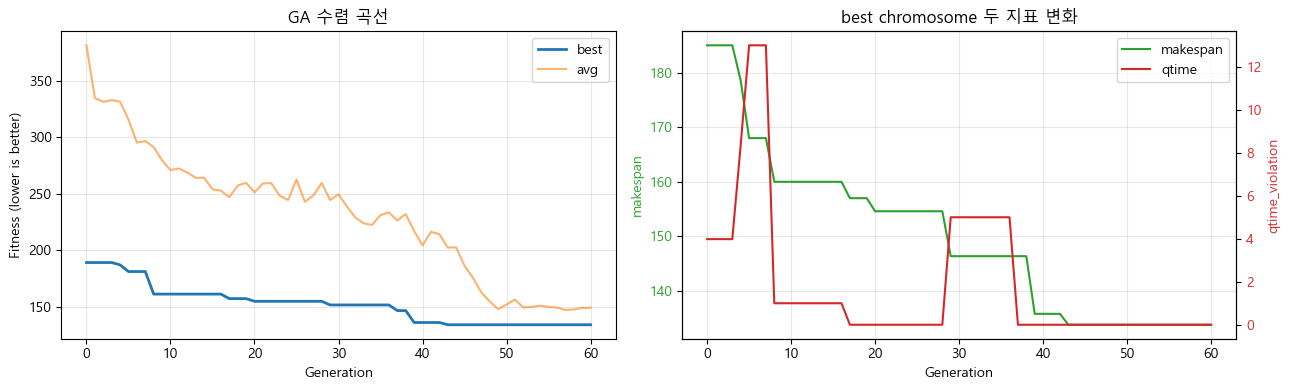

In [63]:
df_history = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (1) Fitness 수렴 곡선
axes[0].plot(df_history['gen'], df_history['best_fitness'], label='best', color='C0', linewidth=2)
axes[0].plot(df_history['gen'], df_history['avg_fitness'], label='avg', color='C1', alpha=0.6)
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Fitness (lower is better)')
axes[0].set_title('GA 수렴 곡선')
axes[0].legend()
axes[0].grid(alpha=0.3)

# (2) Best chromosome 두 지표 변화
ax2 = axes[1]
l1 = ax2.plot(df_history['gen'], df_history['best_makespan'], label='makespan', color='C2')
ax2.set_xlabel('Generation')
ax2.set_ylabel('makespan', color='C2')
ax2.tick_params(axis='y', labelcolor='C2')

ax2_t = ax2.twinx()
l2 = ax2_t.plot(df_history['gen'], df_history['best_qtime'], label='qtime', color='C3')
ax2_t.set_ylabel('qtime_violation', color='C3')
ax2_t.tick_params(axis='y', labelcolor='C3')

ax2.set_title('best chromosome 두 지표 변화')
ax2.grid(alpha=0.3)

lines = l1 + l2
ax2.legend(lines, [l.get_label() for l in lines], loc='upper right')

plt.tight_layout()
plt.show()

## 초기 vs 최종 비교

In [64]:
init = history[0]
final = history[-1]

print('─── 초기 (gen 0, 무작위) ───')
print(f"  best fitness: {init['best_fitness']:.2f}")
print(f"    makespan:   {init['best_makespan']:.2f}")
print(f"    qtime:      {init['best_qtime']:.2f}")
print(f"  avg  fitness: {init['avg_fitness']:.2f}")
print()
print('─── 최종 (GA 진화 후) ───')
print(f"  best fitness: {final['best_fitness']:.2f}")
print(f"    makespan:   {final['best_makespan']:.2f}")
print(f"    qtime:      {final['best_qtime']:.2f}")
print(f"  avg  fitness: {final['avg_fitness']:.2f}")
print()

def pct_change(initial, final_val):
    """초기값이 0이면 절대 변화량 표시, 아니면 변화율(%) 표시."""
    if initial == 0:
        return f'{initial:.2f} → {final_val:.2f} (초기값 0이라 변화율 미정의)'
    return f'{(final_val - initial) / initial * 100:+.1f}%'

print(f'best fitness 개선율: {pct_change(init["best_fitness"], final["best_fitness"])}')
print(f'makespan 변화율:     {pct_change(init["best_makespan"], final["best_makespan"])}')
print(f'qtime 변화율:        {pct_change(init["best_qtime"], final["best_qtime"])}')

─── 초기 (gen 0, 무작위) ───
  best fitness: 188.98
    makespan:   185.00
    qtime:      3.98
  avg  fitness: 381.62

─── 최종 (GA 진화 후) ───
  best fitness: 133.82
    makespan:   133.82
    qtime:      0.00
  avg  fitness: 148.95

best fitness 개선율: -29.2%
makespan 변화율:     -27.7%
qtime 변화율:        -100.0%


## 최종 best chromosome 정보

In [65]:
sim_input_best = decode(best, encoded)

print('─── best chromosome fitness ───')
print(f'  makespan: {best.fitness[0]:.2f}')
print(f'  qtime:    {best.fitness[1]:.2f}')
print()
print('─── 디코딩 결과 (시뮬 실제 입력) ───')
print(f'  job 투입 순서: {sim_input_best.job_priority}')
print()
print(f'  pm_thresholds: {sim_input_best.pm_thresholds}')
print()
print('  op별 머신 할당 (앞 10개):')
for op, m in list(sim_input_best.op_machine.items())[:10]:
    print(f'    {op} → {m}')

─── best chromosome fitness ───
  makespan: 133.82
  qtime:    0.00

─── 디코딩 결과 (시뮬 실제 입력) ───
  job 투입 순서: ['J10', 'J3', 'J6', 'J2', 'J9', 'J4', 'J8', 'J1', 'J5', 'J7']

  pm_thresholds: {'M1': 0.5, 'M2': 0.05, 'M3': 0.1, 'M4': 0.05, 'M5': 0.1, 'M6': 0.2, 'M7': 0.1, 'M8': 0.1}

  op별 머신 할당 (앞 10개):
    J1_O1 → M1
    J1_O2 → M4
    J1_O3 → M2
    J1_O4 → M7
    J2_O1 → M2
    J2_O2 → M4
    J2_O3 → M6
    J3_O1 → M3
    J3_O2 → M5
    J3_O3 → M2


## Best chromosome 시뮬레이션 + 간트 차트

GA가 찾아낸 best chromosome으로 시뮬레이션을 한 번 더 돌려 간트 차트 시각화.

In [66]:
# best chromosome으로 시뮬레이션 재실행 (시드 고정 → fitness와 동일 결과)
random.seed(ga.evaluator.seed)

env = simpy.Environment()
event_logger = EventLogger(env)
scheduler = Scheduler(
    env=env,
    data=data,
    event_logger=event_logger,
    pm_hazard_threshold=0.0,
    job_priority=sim_input_best.job_priority,
    op_machine=sim_input_best.op_machine,
    pm_thresholds=sim_input_best.pm_thresholds,
)
env.run(until=scheduler.job_chk_process)

fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=env.now,
    title=f'GA Best Chromosome 간트 차트 (Simulation Time: {round(env.now, 3)})'
)
fig.show()